In [1]:
import sys, platform
import numpy as np, pandas as pd, matplotlib, sklearn
print("Python:", sys.version.split()[0])
print("OS:", platform.platform())
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("matplotlib:", matplotlib.__version__)
print("scikit-learn:", sklearn.__version__)


Python: 3.13.15
OS: Linux-6.6.122+-x86_64-with-glibc2.39
pandas: 2.2.3
numpy: 2.1.3
matplotlib: 3.10.0
scikit-learn: 1.6.1


# **Simulation d'une base de donnée**

In [5]:

rng = np.random.default_rng(42)
n = 250  # small enough to keep it readable for students

account_id = np.arange(1, n+1)

# Simple date range
dates = pd.date_range("2022-01-01", periods=n, freq="7D")
origination_date = dates[rng.integers(0, len(dates), size=n)]

age = rng.integers(21, 70, size=n)
Revenu = rng.normal(38000, 12000, size=n).clip(12000, 120000)
credit_limit = rng.normal(4500, 2000, size=n).clip(400, 15000)
balance = (credit_limit * rng.uniform(0.05, 1.1, size=n)).clip(0, None)
days_past_due = (rng.integers(0, 90, size=n) * rng.choice([0,1], size=n, p=[0.7,0.3])).astype(int)

# Caractéristiques techniques
dti = (balance / np.maximum(Revenu/12, 1)).clip(0, 15)  # dti : (Debt-to-Revenu)
util = (balance / np.maximum(credit_limit, 1)).clip(0, 3)  # utilisation du credit

# Creation d'un signal de type PD pour les défauts (logit avec un certain niveau de bruit).
z = -2.2 + 0.9*(util>0.8) + 0.6*(dti>0.5) + 0.015*(days_past_due) + 0.003*(70-age) + rng.normal(0, 0.5, size=n)
p_default = 1/(1+np.exp(-z))
default_flag = (rng.uniform(0,1,size=n) < p_default).astype(int)

df = pd.DataFrame({
    "account_id": account_id,
    "origination_date": origination_date,
    "age": age,
    "Revenu": Revenu.round(2),
    "credit_limit": credit_limit.round(2),
    "balance": balance.round(2),
    "days_past_due": days_past_due,
    "dti": dti.round(3),
    "util": util.round(3),
    "default_flag": default_flag
})

df.head()

,account_id,origination_date,age,Revenu,credit_limit,balance,days_past_due,dti,util,default_flag
0,1,2022-06-04,29,36868.85,5233.06,3389.31,67,1.103,0.648,1
1,2,2025-09-13,45,16907.26,3927.50,2630.27,67,1.867,0.670,0
2,3,2025-02-15,30,20395.46,5407.93,5093.77,0,2.997,0.942,0
3,4,2024-02-03,37,63550.97,3882.65,213.46,89,0.040,0.055,0
4,5,2024-01-27,53,22550.93,6371.09,6027.30,0,3.207,0.946,1


# **Visualisation des données**

In [10]:
print("Shape:", df.shape)
display(df.head(10))
df.info()
df.describe().T

Shape: (250, 10)


,account_id,origination_date,age,Revenu,credit_limit,balance,days_past_due,dti,util,default_flag
0,1,2022-06-04,29,36868.85,5233.06,3389.31,67,1.103,0.648,1
1,2,2025-09-13,45,16907.26,3927.50,2630.27,67,1.867,0.670,0
2,3,2025-02-15,30,20395.46,5407.93,5093.77,0,2.997,0.942,0
3,4,2024-02-03,37,63550.97,3882.65,213.46,89,0.040,0.055,0
4,5,2024-01-27,53,22550.93,6371.09,6027.30,0,3.207,0.946,1
5,6,2026-02-07,28,24838.57,837.19,586.09,47,0.283,0.700,1
6,7,2022-05-28,54,60042.96,3828.79,845.70,0,0.169,0.221,0
7,8,2025-05-03,26,72860.81,518.38,446.62,0,0.074,0.862,1
8,9,2022-12-17,29,23941.20,1509.88,1431.77,0,0.718,0.948,0
9,10,2022-06-11,49,33581.01,7227.72,2291.02,0,0.819,0.317,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   account_id        250 non-null    int64         
 1   origination_date  250 non-null    datetime64[ns]
 2   age               250 non-null    int64         
 3   Revenu            250 non-null    float64       
 4   credit_limit      250 non-null    float64       
 5   balance           250 non-null    float64       
 6   days_past_due     250 non-null    int64         
 7   dti               250 non-null    float64       
 8   util              250 non-null    float64       
 9   default_flag      250 non-null    int64         
dtypes: datetime64[ns](1), float64(5), int64(4)
memory usage: 19.7 KB


,count,mean,min,25%,50%,75%,max,std
account_id,250.0,125.5,1.0,63.25,125.5,187.75,250.0,72.312977
origination_date,250,2024-06-01 23:31:12,2022-01-08 00:00:00,2023-04-30 18:00:00,2024-05-21 12:00:00,2025-07-24 06:00:00,2026-10-10 00:00:00,NaN
age,250.0,44.596,21.0,32.0,44.0,57.0,69.0,14.606237
Revenu,250.0,38524.28972,12000.0,30771.7925,38981.32,46314.335,72860.81,12008.510729
credit_limit,250.0,4268.70452,400.0,2777.7,4181.165,5609.1725,9598.66,1998.925646
balance,250.0,2527.53456,74.19,982.2525,1995.19,3587.7125,9315.94,2019.201904
days_past_due,250.0,13.172,0.0,0.0,0.0,14.5,89.0,24.593205
dti,250.0,0.918496,0.026,0.286,0.626,1.1935,5.847,0.897998
util,250.0,0.581,0.052,0.30875,0.5865,0.85175,1.093,0.309721
default_flag,250.0,0.204,0.0,0.0,0.0,0.0,1.0,0.403777


# Sommaire

In [11]:
# Taux de défaut global
overall_dr = df["default_flag"].mean()
print(f"Le taux de défaut global est: {overall_dr:.2%}")

# Tranches d'utilisation
util_bins = pd.cut(df["util"], bins=[-0.01, 0.3, 0.6, 0.9, 1.2, 3.0], labels=["<=0.3","(0.3,0.6]","(0.6,0.9]","(0.9,1.2]","(1.2,3.0]"])
util_summary = df.groupby(util_bins, observed=False)["default_flag"].agg(["count","mean"]).rename(columns={"mean":"default_rate"})
display(util_summary)

# Tranches des retards
dpd_bins = pd.cut(df["days_past_due"], bins=[-1,0,30,60,120], labels=["0","1-30","31-60","61-120"])
dpd_summary = df.groupby(dpd_bins, observed=False)["default_flag"].agg(["count","mean"]).rename(columns={"mean":"default_rate"})
display(dpd_summary)

Le taux de défaut global est: 20.40%


,count,default_rate
util,,
<=0.3,60,0.083333
"(0.3,0.6]",70,0.114286
"(0.6,0.9]",67,0.313433
"(0.9,1.2]",53,0.320755
"(1.2,3.0]",0,NaN


,count,default_rate
days_past_due,,
0,180,0.150000
1-30,21,0.238095
31-60,26,0.384615
61-120,23,0.391304


# VISUALISATION DES DONNÉES

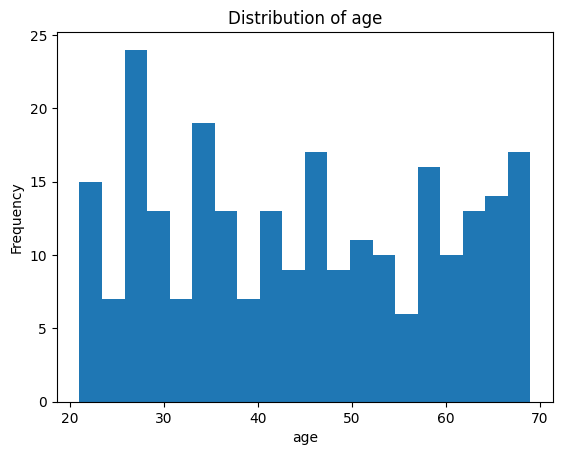

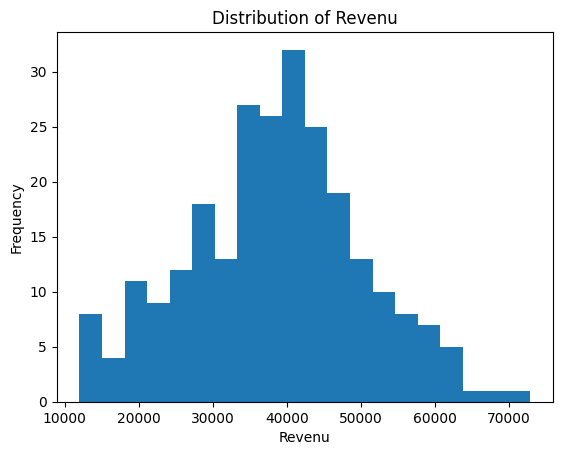

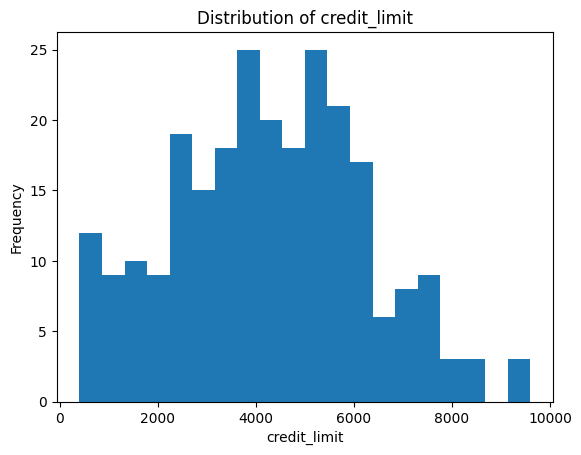

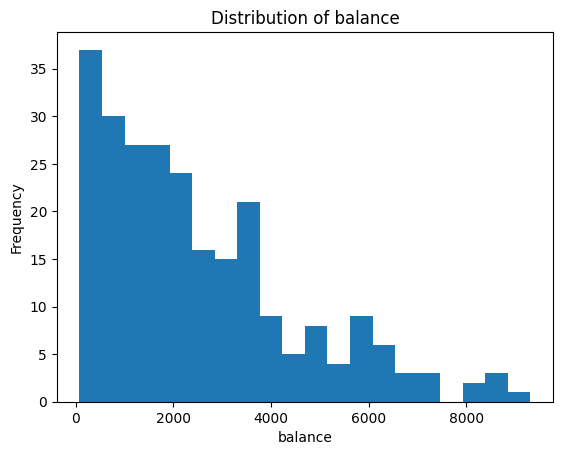

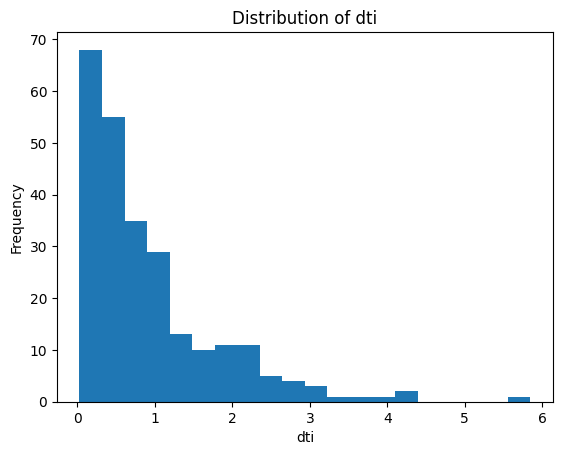

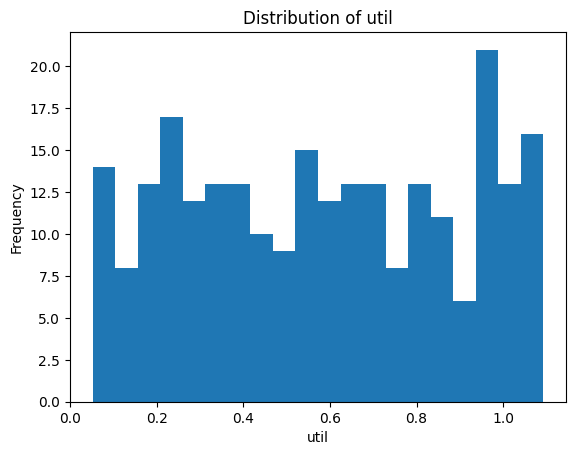

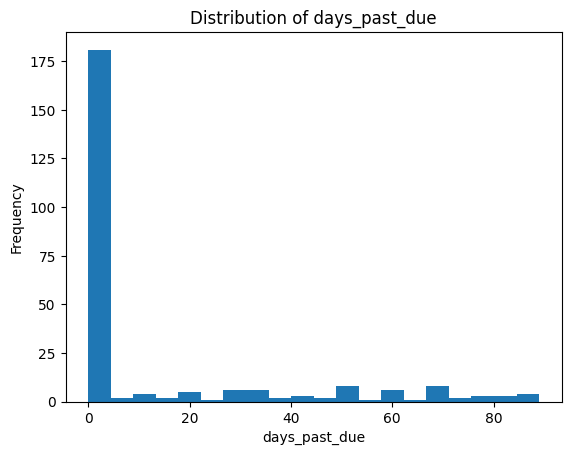

In [13]:
# Histogramme des variables quantitatives
import matplotlib.pyplot as plt

numeric_cols = ["age","Revenu","credit_limit","balance","dti","util","days_past_due"]
for col in numeric_cols:
    plt.figure()
    plt.hist(df[col].dropna(), bins=20)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()


<Figure size 640x480 with 0 Axes>

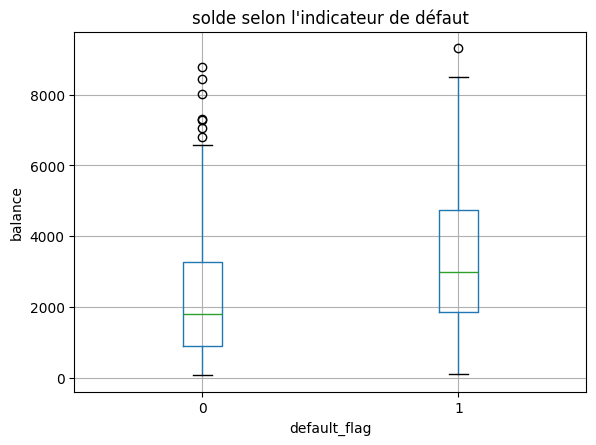

In [14]:
# Boxplot: solde selon l'indicateur de défaut
import matplotlib.pyplot as plt

plt.figure()
df.boxplot(column="balance", by="default_flag")
plt.title("solde selon l'indicateur de défaut")
plt.suptitle("")
plt.xlabel("default_flag")
plt.ylabel("balance")
plt.show()

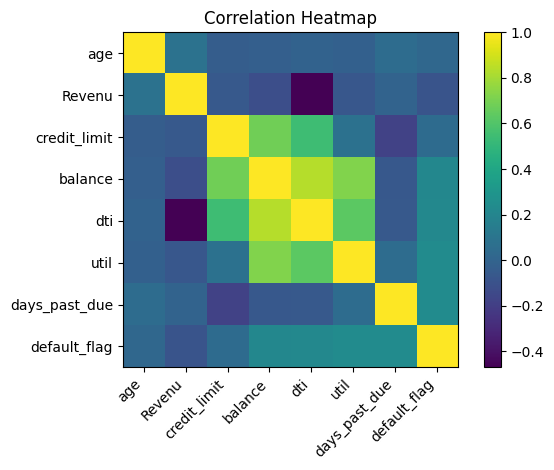

In [15]:
# Matrice de Correlation
import numpy as np
import matplotlib.pyplot as plt

corr = df[numeric_cols + ["default_flag"]].corr()
plt.figure()
plt.imshow(corr, interpolation="nearest")
plt.title("Correlation Heatmap")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.index)), corr.index)
plt.colorbar()
plt.tight_layout()
plt.show()

In [19]:
# Tranches d'utilisation + sommaire

import pandas as pd

util_bins = pd.cut(
    df["util"],
    bins=[-0.01, 0.3, 0.6, 0.9, 1.2, 3.0],
    labels=["<=0.3","(0.3,0.6]","(0.6,0.9]","(0.9,1.2]","(1.2,3.0]"]
)
util_bins.name = "util_bucket"  # <-- attribution de nom

util_summary = (
    df.groupby(util_bins, observed=False)["default_flag"]
      .agg(["count","mean"])
      .rename(columns={"mean":"default_rate"})
)

util_plot = util_summary.reset_index()  # has "util_bucket" column
util_plot



,util_bucket,count,default_rate
0,<=0.3,60,0.083333
1,"(0.3,0.6]",70,0.114286
2,"(0.6,0.9]",67,0.313433
3,"(0.9,1.2]",53,0.320755
4,"(1.2,3.0]",0,NaN


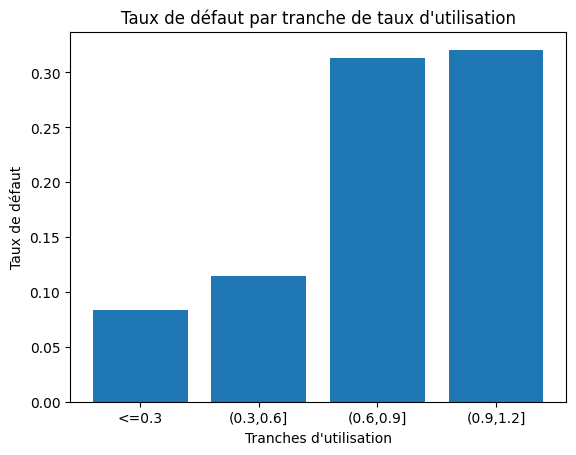

In [21]:
# --- Bar plot: taux de defaut par tranche d'utilisation
import matplotlib.pyplot as plt

plt.figure()
plt.bar(util_plot["util_bucket"].astype(str), util_plot["default_rate"])
plt.title("Taux de défaut par tranche de taux d'utilisation")
plt.xlabel("Tranches d'utilisation")
plt.ylabel("Taux de défaut")
plt.xticks(rotation=0)
plt.show()

# **Régression logistique**

Accuracy: 0.7778
Confusion matrix:
 [[49  1]
 [13  0]]
AUC: 0.6877


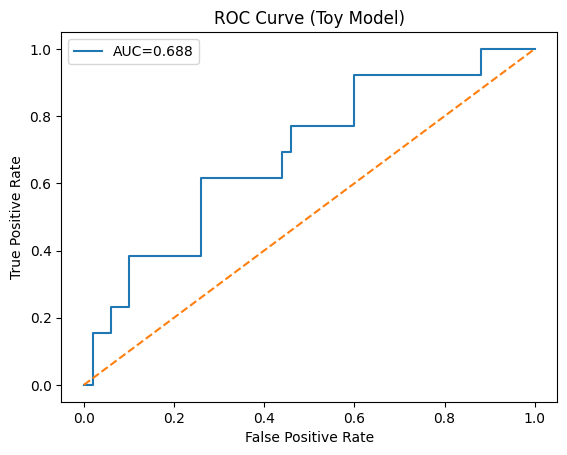

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve

X = df[["age","Revenu","util","dti","days_past_due"]].copy()
y = df["default_flag"].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=123, stratify=y)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:,1]

acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("Accuracy:", round(acc, 4))
print("Confusion matrix:\n", cm)
print("AUC:", round(auc, 4))

# Courbe du ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
import matplotlib.pyplot as plt
plt.figure()
plt.plot(fpr, tpr, label=f"AUC={auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve (Toy Model)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [24]:
# Exporter les données simuées
df.to_csv("Donnée_pret_bancaire_sim.csv", index=False)
print("Saved Donnée_pret_bancaire_sim.csv")


Saved Donnée_pret_bancaire_sim.csv
